In [1]:
import seaborn as sns
import pandas as pd
import av
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

In [2]:
ecg_video_path = Path("./datasets/EchoNet-Dynamic/videos")
file_name_df = pd.read_csv("./datasets/EchoNet-Dynamic/FileList.csv")

In [3]:
# iterate through each file in the df
num_frames = []
train_frames = []
test_frames = []

for file_name in file_name_df["FileName"]:
    obj = av.open(ecg_video_path / (file_name + ".avi"))

    # get # of frames for all videos
    num_frames.append(len(list(obj.decode(video=0))))

    obj = av.open(ecg_video_path / (file_name + ".avi"))

    for frame in obj.decode(video=0):
        split = file_name_df.loc[file_name_df["FileName"] == file_name, "Split"].values[0]

        if split == "TRAIN":
            train_frames.append(frame)
        elif split == "VAL":
            test_frames.append(frame)

# divide by total # of videos
print(f"Average # of frames per video: {sum(num_frames) / file_name_df.shape[0]}")

Average # of frames per video: 176.53399800598206


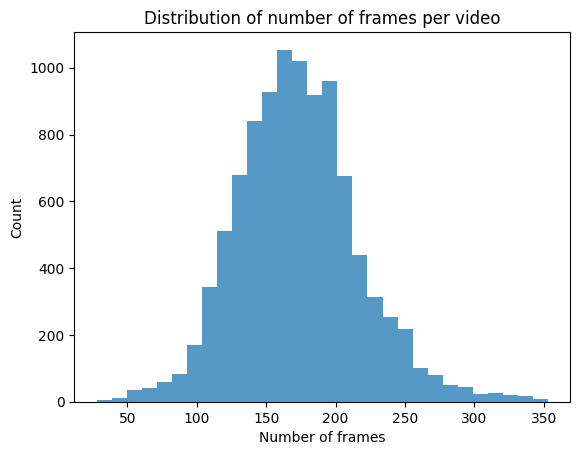

In [4]:
num_frames = np.array(num_frames)

plot = sns.histplot(num_frames[num_frames < np.quantile(num_frames, q=0.99)], edgecolor=None, bins=30)
plot.set_title("Distribution of number of frames per video")
plot.set_xlabel("Number of frames")

plt.show()

In [5]:
print(len(train_frames))
print(len(test_frames))

print(len(train_frames) + len(test_frames), sum(num_frames))

print(sum(num_frames) - (len(train_frames) + len(test_frames)))

1315340
228836
1544176 1770636
226460


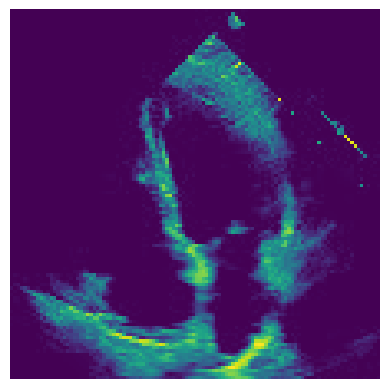

In [ ]:
img = train_frames[1].to_ndarray(format="gray")

plt.imshow(img)
plt.axis("off")
plt.show()

print(img.dtype)